# IMDb Sentiment — Part B: Mean-Pool MLP

Reference architecture: Embedding → MeanPool → Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear.
Includes sweeps for depth, embedding size, and dropout. Keeps per-run checkpoints and also copies the best test-accuracy run to `../checkpoints/mlp_best.pt` for convenience.

In [25]:
# Imports and setup
import os, sys
import pandas as pd
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from pathlib import Path
import shutil

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.preprocess import (
    prepare_imdb_splits,
    build_vocab,
    TextDataset,
    collate_fn,
)
from src.mlp_model import MLPClassifier
from src.train import set_seed, train_model
from src.evaluate import evaluate, plot_learning_curves

set_seed(42)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

## 1) Load dataset and build vocabulary
70/10/20 split (stratified), then build vocabulary (default 20k) and fixed-length sequences.

In [26]:
# Config
VOCAB_SIZE = 30000  # try 10000, 20000, 30000
MAX_LEN = 256       # ~90th percentile from EDA
BATCH_SIZE = 128

raw_ds = load_dataset("imdb")
train_ds, val_ds, test_ds = prepare_imdb_splits(raw_ds, seed=42)

vocab = build_vocab(train_ds["text"], max_tokens=VOCAB_SIZE)
len(vocab)

30000

In [27]:
# Torch datasets/dataloaders
train_dataset = TextDataset(train_ds["text"], train_ds["label"], vocab=vocab, max_len=MAX_LEN)
val_dataset = TextDataset(val_ds["text"], val_ds["label"], vocab=vocab, max_len=MAX_LEN)
test_dataset = TextDataset(test_ds["text"], test_ds["label"], vocab=vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

len(train_loader), len(val_loader), len(test_loader)

(274, 40, 79)

## 2) Define the MLP model
Embedding → MeanPool → stacked Linear/ReLU/Dropout → Linear output.

In [28]:
def make_model(embed_dim: int, hidden_dims, dropout: float):
    model = MLPClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dims=hidden_dims,
        num_classes=2,
        dropout=dropout,
    )
    return model.to(device)

sample_model = make_model(embed_dim=128, hidden_dims=[256, 128], dropout=0.3)
sample_model

MLPClassifier(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)

## 3) Training helper
Runs train/val for N epochs, saves best (by val acc) checkpoint for that run, reports test metrics.

In [29]:
def run_experiment(embed_dim: int, hidden_dims, dropout: float, lr: float = 1e-3, weight_decay: float = 1e-5, epochs: int = 5, run_name: str = "exp"):
    model = make_model(embed_dim=embed_dim, hidden_dims=hidden_dims, dropout=dropout)
    ckpt_path = Path("..").joinpath("checkpoints", f"{run_name}.pt")
    history = train_model(
        model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=lr,
        weight_decay=weight_decay,
        device=device,
        checkpoint_path=str(ckpt_path),
    )
    test_loss, test_acc = evaluate(model, test_loader, torch.nn.CrossEntropyLoss(), device)
    return {
        "run": run_name,
        "embed_dim": embed_dim,
        "hidden_dims": list(hidden_dims),
        "dropout": dropout,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "history": history,
        "checkpoint": str(ckpt_path),
    }

## 4) Required experiments (enable by setting flags)
- Experiment 1: Depth (1/2/3 hidden layers)
- Experiment 2: Embedding dim (64/128/256)
- Experiment 3: Dropout (0.2/0.3/0.5)

In [30]:
run_depth = False
run_emb = False
run_drop = True

In [31]:
if run_depth:
    depth_settings = [[256], [256, 128], [512, 256, 128]]
    depth_results = []
    for i, hidden_dims in enumerate(depth_settings, start=1):
        depth_results.append(run_experiment(embed_dim=128, hidden_dims=hidden_dims, dropout=0.3, run_name=f"depth_{i}"))
    depth_df = pd.DataFrame([
        {"run": r["run"], "hidden_dims": r["hidden_dims"], "test_acc": r["test_acc"], "checkpoint": r["checkpoint"]}
        for r in depth_results
    ])
    display(depth_df)

In [32]:
if run_emb:
    emb_results = []
    for emb in [64, 128, 256]:
        emb_results.append(run_experiment(embed_dim=emb, hidden_dims=[256, 128], dropout=0.3, run_name=f"emb_{emb}"))
    emb_df = pd.DataFrame([
        {"run": r["run"], "embed_dim": r["embed_dim"], "test_acc": r["test_acc"], "checkpoint": r["checkpoint"]}
        for r in emb_results
    ])
    display(emb_df)

In [33]:
if run_drop:
    drop_results = []
    for drop in [0.2, 0.3, 0.5]:
        drop_results.append(run_experiment(embed_dim=128, hidden_dims=[256, 128], dropout=drop, run_name=f"drop_{drop}"))
    drop_df = pd.DataFrame([
        {"run": r["run"], "dropout": r["dropout"], "test_acc": r["test_acc"], "checkpoint": r["checkpoint"]}
        for r in drop_results
    ])
    display(drop_df)

train:   0%|          | 0/274 [00:00<?, ?it/s]

eval:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01 | train loss 0.5235 acc 0.7268 | val loss 0.3850 acc 0.8284 | best val acc 0.8284


train:   0%|          | 0/274 [00:00<?, ?it/s]

eval:   0%|          | 0/40 [00:00<?, ?it/s]

...

train:   0%|          | 0/274 [00:00<?, ?it/s]

eval:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 05 | train loss 0.2007 acc 0.9250 | val loss 0.3219 acc 0.8784 | best val acc 0.8792


eval:   0%|          | 0/79 [00:00<?, ?it/s]

,run,dropout,test_acc,checkpoint
0,drop_0.2,0.2,0.877312,../checkpoints/drop_0.2.pt
1,drop_0.3,0.3,0.876312,../checkpoints/drop_0.3.pt
2,drop_0.5,0.5,0.872713,../checkpoints/drop_0.5.pt


## 5) Select best run and copy to `mlp_best.pt`
Chooses the highest test accuracy among executed runs and copies its checkpoint to `../checkpoints/mlp_best.pt`. Per-run checkpoints are retained for plotting.

In [34]:
all_results = []
if 'depth_results' in globals():
    all_results.extend(depth_results)
if 'emb_results' in globals():
    all_results.extend(emb_results)
if 'drop_results' in globals():
    all_results.extend(drop_results)

if not all_results:
    print("No experiment results found. Run one of the sweeps first (set run_depth/run_emb/run_drop to True).")
else:
    best = max(all_results, key=lambda r: r.get("test_acc", 0.0))
    best_ckpt = Path(best["checkpoint"])
    dst = Path("..").joinpath("checkpoints", "mlp_best.pt")
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(best_ckpt, dst)
    print(f"Selected run {best['run']} (test_acc={best['test_acc']:.4f}) -> {dst}")
    best_summary = {k: best[k] for k in ("run", "embed_dim", "hidden_dims", "dropout", "test_acc", "checkpoint")}
    best_summary

Selected run drop_0.2 (test_acc=0.8773) -> ../checkpoints/mlp_best.pt


## 6) Plotting training curves
Use the stored `history` dict (train/val loss/acc) from any run to inspect overfitting.

Saved learning-curve plot to ../checkpoints/emb_64_curves.png


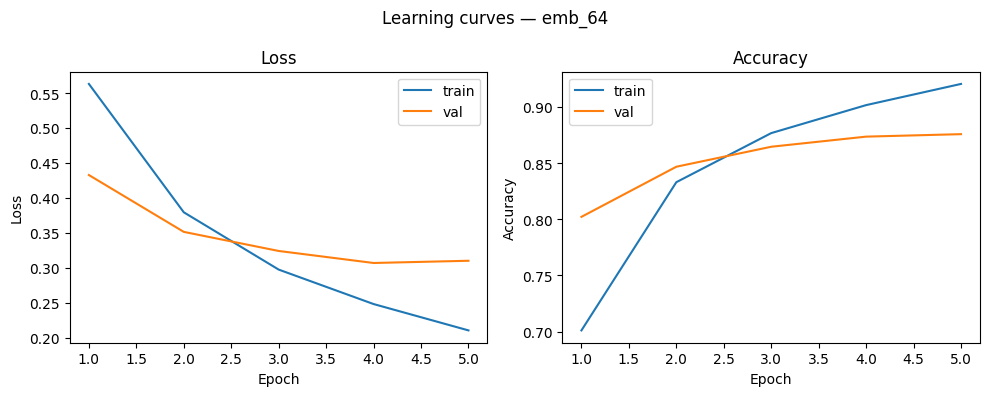

In [36]:
# Example visualization (run after an experiment has executed)
from pathlib import Path
from src.evaluate import plot_learning_curves

def choose_result():
    # Prefer the best run chosen in section 5, otherwise pick the highest test_acc.
    target_run = best_summary.get('run') if 'best_summary' in globals() else None
    pools = []
    for name in ('depth_results', 'emb_results', 'drop_results'):
        if name in globals() and globals()[name]:
            pools.extend(globals()[name])
    if not pools:
        return None
    if target_run:
        for r in pools:
            if r.get('run') == target_run:
                return r
    return max(pools, key=lambda r: r.get('test_acc', 0.0))

result = choose_result()

if result:
    history = result["history"]
    run_name = result["run"]
    fig, _ = plot_learning_curves(history, title=f"Learning curves — {run_name}")
    save_path = Path('..').joinpath('checkpoints', f"{run_name}_curves.png")
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight')
    print(f"Saved learning-curve plot to {save_path}")
else:
    print('No history found; run an experiment first (set run_depth/run_emb/run_drop to True).')


## 7) Notes
- Adjust `BATCH_SIZE`, `MAX_LEN`, and `epochs` for your M4 GPU if memory is tight.
- Per-run checkpoints are kept for analysis; the best-by-test-acc run is also copied to `../checkpoints/mlp_best.pt`.